# Navigating Supply Chain Volatility: A Predictive 3-Class Model for Stockout

# Problem Statement

How can we transform high-dimensional supply chain data into a predictive classification system that categorizes inventory into actionable risk states—No Stockout, Potential Stockout, or Stockout—while mathematically pruning redundant noise through regularization?

## Underlying Challenge

The project addresses the challenge of inventory imbalance within global supply chains.

## Goal

The ultimate goal is to provide a prescriptive tool to minimize the financial "Twin Pillars of Waste": lost revenue from stockouts and trapped capital from excess inventory.

Achieving the ideal inventory balance is known as the classic "Goldilocks" problem in supply chain management.

# Loading Data

In [1]:
import kagglehub
import pandas as pd

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Download latest version
# https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/data
path = kagglehub.dataset_download("shashwatwork/dataco-smart-supply-chain-for-big-data-analysis")
original_data = pd.read_csv(path + "/DataCoSupplyChainDataset.csv", encoding='latin1')
raw_data = original_data.copy()

Using Colab cache for faster access to the 'dataco-smart-supply-chain-for-big-data-analysis' dataset.


In [3]:
raw_data.sample(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
87225,PAYMENT,3,4,10.660000,41.000000,Advance shipping,0,24,Women's Apparel,Saint Louis,...,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,7/14/2015 14:37,Standard Class
28672,PAYMENT,2,1,6.750000,89.980003,Late delivery,1,29,Shop By Sport,Warren,...,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,6/17/2017 21:31,First Class
36586,PAYMENT,2,2,-172.789993,287.980011,Shipping on time,0,43,Camping & Hiking,Massillon,...,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,9/9/2016 10:31,Second Class
116374,TRANSFER,2,1,29.950001,115.180000,Late delivery,1,17,Cleats,Brooklyn,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,5/4/2015 14:43,First Class
18863,PAYMENT,2,1,32.570000,113.089996,Late delivery,1,18,Men's Footwear,Tonawanda,...,NaN,403,18,NaN,http://images.acmesports.sports/Nike+Men%27s+C...,Nike Men's CJ Elite 2 TD Football Cleat,129.990005,0,11/14/2015 16:33,First Class


# Exploratory Data Analysis
Exploratory Data Analysis (EDA) serves as a foundational phase in machine learning, designed to deepen data understanding prior to model implementation.

By performing this essential step, we can uncover patterns, pinpoint inaccuracies, and develop hypotheses regarding variable interactions, ensuring the data is effectively structured for the modeling process.

**Number of rows, columns**

In [4]:
print(raw_data.shape)

(180519, 53)


**Data Info**

In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

The dataset contains 180,519 entries (rows) and 53 columns initially.

**Descriptive Statistics of Numerical Variables**

In [6]:
raw_data.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


**Descriptive Statistics of Categorical Variables**

In [7]:
raw_data.describe(include=['object', 'category'])

,Type,Delivery Status,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Lname,Customer Password,Customer Segment,...,Order City,Order Country,order date (DateOrders),Order Region,Order State,Order Status,Product Image,Product Name,shipping date (DateOrders),Shipping Mode
count,180519,180519,180519,180519,180519,180519,180519,180511,180519,180519,...,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519
unique,4,4,50,563,2,1,782,1109,1,3,...,3597,164,65752,23,1089,9,118,118,63701,4
top,DEBIT,Late delivery,Cleats,Caguas,EE. UU.,XXXXXXXXX,Mary,Smith,XXXXXXXXX,Consumer,...,Santo Domingo,Estados Unidos,1/4/2017 2:28,Central America,Inglaterra,COMPLETE,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,4/17/2015 22:16,Standard Class
freq,69295,98977,24551,66770,111146,180519,65150,64104,180519,93504,...,2211,24840,5,28341,6722,59491,24515,24515,10,107752


## Defining Stockout Temp Variable

To define a 'Stockout' event, we can analyze 'Order Status' and 'Delivery Status'. By identifying orders marked as 'Cancelled' or deliveries with a 'Shipping canceled' status, we can identify potential stockouts. Consequently, we will generate Is_Stockout as a new binary column for this analysis.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Define 'Is_Stockout' based on 'Order Status' and 'Delivery Status'
raw_data['Is_Stockout'] = ((raw_data['Order Status'] == 'CANCELED') | (raw_data['Delivery Status'] == 'Shipping canceled')).astype(int)

In [10]:
raw_data['Is_Stockout'].value_counts()

,count
Is_Stockout,
0,172765
1,7754


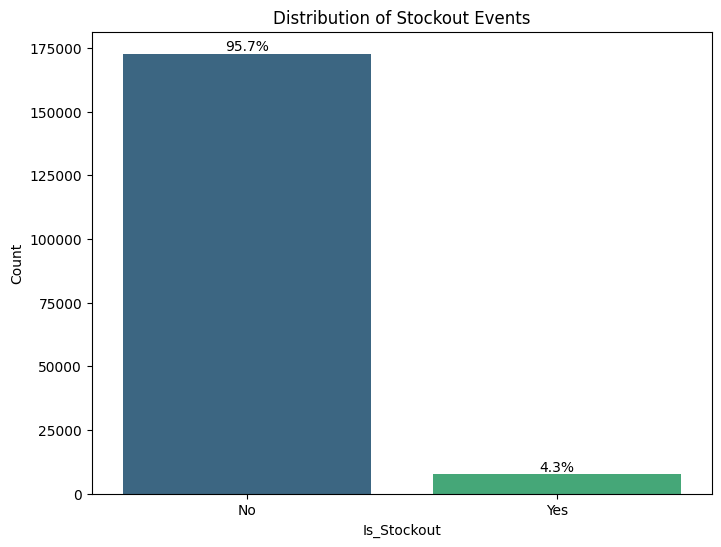

In [11]:
# visualize is_stockout column
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Is_Stockout', data=raw_data, palette='viridis')
plt.title('Distribution of Stockout Events')
plt.xlabel('Is_Stockout')
# put the percentages on the bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/len(raw_data))
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Yes'])
plt.ylabel('Count')
plt.show()

## Defining a Multi Class Target Column for Stockout

Building upon our `Is_Stockout` definition and the `Late_delivery_risk` column, we can create a more granular 3-class target variable to categorize different levels of stockout severity or risk. This can be beneficial for models that need to distinguish between 'no problem', 'potential problem', and 'confirmed problem'.


Now that the Is_Stockout column is correctly defined, we will create the Stockout_Class column as planned. This column will categorize stockout risk into three classes: 'No Stockout', 'Late Delivery Risk (Potential Stockout)', and 'Confirmed Stockout'.

In [12]:
# Initialize the new 3-class target column
# Class 0: No Stockout
raw_data['Stockout_Class'] = 0  # Default to 'No Stockout'

# Class 1: Potential Stockout
# These are orders not confirmed as stockout, but had late delivery risk
raw_data.loc[(raw_data['Is_Stockout'] == 0) & (raw_data['Late_delivery_risk'] == 1), 'Stockout_Class'] = 1

# Class 2: Stockout
# These are orders where Is_Stockout is 1
raw_data.loc[raw_data['Is_Stockout'] == 1, 'Stockout_Class'] = 2

**Value counts for 'Stockout_Class' column**

In [13]:
# Define the mapping from numbers to labels
stockout_class_mapping = {
    0: 'No Stockout',
    1: 'Potential Stockout',
    2: 'Stockout'
}

# Create a new column with the mapped labels
raw_data['Stockout_Class_Label'] = raw_data['Stockout_Class'].map(stockout_class_mapping)

display(raw_data['Stockout_Class_Label'].value_counts())
display(raw_data['Stockout_Class_Label'].value_counts(normalize=True))

,count
Stockout_Class_Label,
Potential Stockout,98977
No Stockout,73788
Stockout,7754


,proportion
Stockout_Class_Label,
Potential Stockout,0.548291
No Stockout,0.408755
Stockout,0.042954


## Distribution of the Stockout Classes

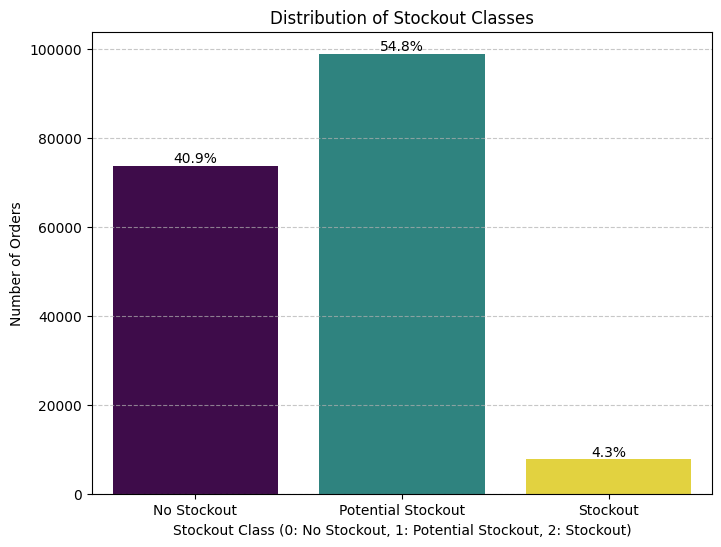

In [14]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Stockout_Class', hue='Stockout_Class', data=raw_data, palette='viridis', legend=False)
plt.title('Distribution of Stockout Classes')
plt.xlabel('Stockout Class (0: No Stockout, 1: Potential Stockout, 2: Stockout)')
plt.ylabel('Number of Orders')
plt.xticks(ticks=[0, 1, 2], labels=['No Stockout', 'Potential Stockout', 'Stockout'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Calculate total count for percentages
total = len(raw_data['Stockout_Class'])

# Add the numerical values (percentages) on top of the bars
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

# Feature Engineering

In [50]:
data = raw_data.copy()

## Cleaning target specific features - fully correlated

In [51]:
data = data.drop(columns=['Order Status', 'Delivery Status', 'Late_delivery_risk', 'Is_Stockout', 'Stockout_Class_Label'])

## Cleaning Irrelevant Features

Based on our current dataset, the following columns appear to be irrelevant for predicting stockout status:

*   **Customer Email:** This is a personal identifier and offers no predictive value for stockouts.

*   **Customer Fname and Customer Lname:** First and last names are personal identifiers and not relevant.

*   **Customer Password:** Sensitive personal data, completely irrelevant for stockout prediction.

*   **Customer Street:** Specific address information, too granular and generally not predictive of stockouts.

*   **Customer Id:** A unique identifier for each customer. While useful for linking data, the ID itself is not a predictive feature for stockouts.

*   **Order Id:** A unique identifier for each order, not a predictive feature.

*   **Order Item Id:** A unique identifier for each item within an order, not a predictive feature.

*   **Product Card Id:** A product identifier, often redundant if Product Category Id or Product Name are available and more generalized.

*   **Product Image:** A URL to an image, not relevant for numerical prediction.

*   **Product Status:** This column has a standard deviation of 0 and all values are 0 (as seen in raw_data.describe()), meaning it contains no information that can differentiate between stockout and non-stockout events.

These columns can generally be removed to simplify the dataset without losing information relevant to stockout prediction.

In [52]:
irrelevant_columns = [
    'Customer Email',
    'Customer Fname',
    'Customer Lname',
    'Customer Password',
    'Customer Street',
    'Customer Id',
    'Order Id',
    'Order Item Id',
    'Product Card Id',
    'Product Image',
    'Product Status'
]

data = data.drop(columns=irrelevant_columns)
print("Irrelevant columns dropped successfully.")

Irrelevant columns dropped successfully.


## Cleaning Missing Features

In [53]:
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage.round(2) # Round to 2 decimal places
})

# Filter to show only columns with missing values and sort by count
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

display(missing_info)

,Missing Count,Missing Percentage
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Zipcode,3,0.00


In [54]:
data = data.drop(columns=['Order Zipcode', 'Product Description'])
print("Columns 'Order Zipcode' and 'Product Description' have been dropped.")

Columns 'Order Zipcode' and 'Product Description' have been dropped.


In [55]:
median_zipcode = data['Customer Zipcode'].median()
data['Customer Zipcode'] = raw_data['Customer Zipcode'].fillna(median_zipcode)
print("Missing values in 'Customer Zipcode' after imputation:", data['Customer Zipcode'].isnull().sum())

Missing values in 'Customer Zipcode' after imputation: 0


## Cleaning the features with one distinct value

In [56]:
print("Columns with only one distinct value in data:")
single_value_cols = []
for col in data.columns:
    if data[col].nunique() == 1:
        single_value_cols.append(col)
        print(f"{col}: {data[col].unique()}")

if single_value_cols:
    data = data.drop(columns=single_value_cols)
    print(f"\nDropped {len(single_value_cols)} columns with only one distinct value.")
    print("Current shape of data:", data.shape)
else:
    print("No columns with only one distinct value found in data.")

Columns with only one distinct value in data:
No columns with only one distinct value found in data.


It appears that no categorical values with a single distinct entry are present.

## Cleaning High Correlated Fields

In [57]:
# Selecting numerical features only
df_numeric = data.select_dtypes(include=['float64', 'int64'])
df_numeric.corr()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Category Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,...,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Category Id,Product Price,Stockout_Class
Days for shipping (real),1.000000,0.515880,-0.005101,0.001757,-0.000348,0.000113,-0.001631,-0.004073,0.003911,0.003432,...,0.001467,0.002185,-0.004638,-0.000811,0.001962,0.001757,-0.005101,-0.000348,0.002185,0.352340
Days for shipment (scheduled),0.515880,1.000000,-0.000185,0.006445,-0.000367,-0.003019,-0.000262,-0.005300,0.003675,0.000899,...,0.000065,0.006912,-0.001822,-0.002925,0.006327,0.006445,-0.000185,-0.000367,0.006912,-0.329106
Benefit per order,-0.005101,-0.000185,1.000000,0.133484,0.031889,0.002233,0.031442,0.000338,-0.002521,0.009354,...,-0.018644,0.103459,0.823689,0.015696,0.131816,0.133484,1.000000,0.031889,0.103459,-0.005155
Sales per customer,0.001757,0.006445,0.133484,1.000000,0.225201,-0.001304,0.232367,-0.000223,0.001444,0.060181,...,-0.119469,0.781781,-0.001439,0.105413,0.989744,1.000000,0.133484,0.225201,0.781781,-0.004996
Category Id,-0.000348,-0.000367,0.031889,0.225201,1.000000,0.002881,0.888835,0.002195,-0.002320,0.274633,...,0.000572,0.461059,-0.001614,-0.302408,0.227483,0.225201,0.031889,1.000000,0.461059,0.000544
Customer Zipcode,0.000113,-0.003019,0.002233,-0.001304,0.002881,1.000000,0.002868,0.584544,-0.923885,0.002007,...,-0.000139,0.002187,0.003362,-0.006168,-0.001491,-0.001304,0.002233,0.002881,0.002187,0.001834
Department Id,-0.001631,-0.000262,0.031442,0.232367,0.888835,0.002868,1.000000,0.002460,-0.002435,0.136897,...,0.000255,0.446743,-0.003044,-0.265437,0.234718,0.232367,0.031442,0.888835,0.446743,-0.000371
Latitude,-0.004073,-0.005300,0.000338,-0.000223,0.002195,0.584544,0.002460,1.000000,-0.525122,0.002335,...,-0.003889,0.000471,-0.000081,-0.001853,-0.000696,-0.000223,0.000338,0.002195,0.000471,-0.000850
Longitude,0.003911,0.003675,-0.002521,0.001444,-0.002320,-0.923885,-0.002435,-0.525122,1.000000,-0.005146,...,0.000526,-0.000894,-0.003582,0.004467,0.001696,0.001444,-0.002521,-0.002320,-0.000894,-0.002176
Order Customer Id,0.003432,0.000899,0.009354,0.060181,0.274633,0.002007,0.136897,0.002335,-0.005146,1.000000,...,0.001712,0.111118,-0.000337,-0.091328,0.060961,0.060181,0.009354,0.274633,0.111118,0.004263


In [58]:
import numpy as np

**Columns with correlation greater than 0.5 in raw_data**

In [59]:
# Re-select numerical features from raw_data
df_numeric = data.select_dtypes(include=['float64', 'int64', 'int32'])

# Recalculate the correlation matrix
arr_matrix = df_numeric.corr().abs()

threshold_corr = 0.5

# Filter for correlations greater than threshold_corr, excluding self-correlations
upper_tri = arr_matrix.where(np.triu(np.ones(arr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_tri[upper_tri > threshold_corr].stack().rename('correlation')

#print(f"Columns with correlation greater than {threshold_corr} in raw_data:")
display(high_corr_pairs.sort_values(ascending=False))

# Identify columns to drop
columns_to_drop_from_data = set()

for idx, correlation_value in high_corr_pairs.items():
    col1, col2 = idx[0], idx[1]
    if col2 not in columns_to_drop_from_data:
        columns_to_drop_from_data.add(col2)
        print(f"Dropping '{col2}' (correlated with '{col1}', correlation: {correlation_value:.2f})")

if columns_to_drop_from_data:
    print(f"\nIdentified columns to drop: {list(columns_to_drop_from_data)}")
    data = data.drop(columns=list(columns_to_drop_from_data))
    print(f"Dropped {len(columns_to_drop_from_data)} highly correlated columns.")
    print(f"New shape of data: {data.shape}")
else:
    print("\nNo highly correlated columns (above threshold) found to drop.")

,,correlation
Benefit per order,Order Profit Per Order,1.000000
Sales per customer,Order Item Total,1.000000
Category Id,Product Category Id,1.000000
Order Item Product Price,Product Price,1.000000
Category Id,Order Item Cardprod Id,0.991092
Order Item Cardprod Id,Product Category Id,0.991092
Sales,Order Item Total,0.989744
Sales per customer,Sales,0.989744
Customer Zipcode,Longitude,0.923885
Department Id,Order Item Cardprod Id,0.906117


Dropping 'Days for shipment (scheduled)' (correlated with 'Days for shipping (real)', correlation: 0.52)
Dropping 'Order Item Profit Ratio' (correlated with 'Benefit per order', correlation: 0.82)
Dropping 'Order Profit Per Order' (correlated with 'Benefit per order', correlation: 1.00)
Dropping 'Order Item Product Price' (correlated with 'Sales per customer', correlation: 0.78)
Dropping 'Sales' (correlated with 'Sales per customer', correlation: 0.99)
Dropping 'Order Item Total' (correlated with 'Sales per customer', correlation: 1.00)
Dropping 'Product Price' (correlated with 'Sales per customer', correlation: 0.78)
Dropping 'Department Id' (correlated with 'Category Id', correlation: 0.89)
Dropping 'Order Item Cardprod Id' (correlated with 'Category Id', correlation: 0.99)
Dropping 'Product Category Id' (correlated with 'Category Id', correlation: 1.00)
Dropping 'Latitude' (correlated with 'Customer Zipcode', correlation: 0.58)
Dropping 'Longitude' (correlated with 'Customer Zipcode

## Numerical Features

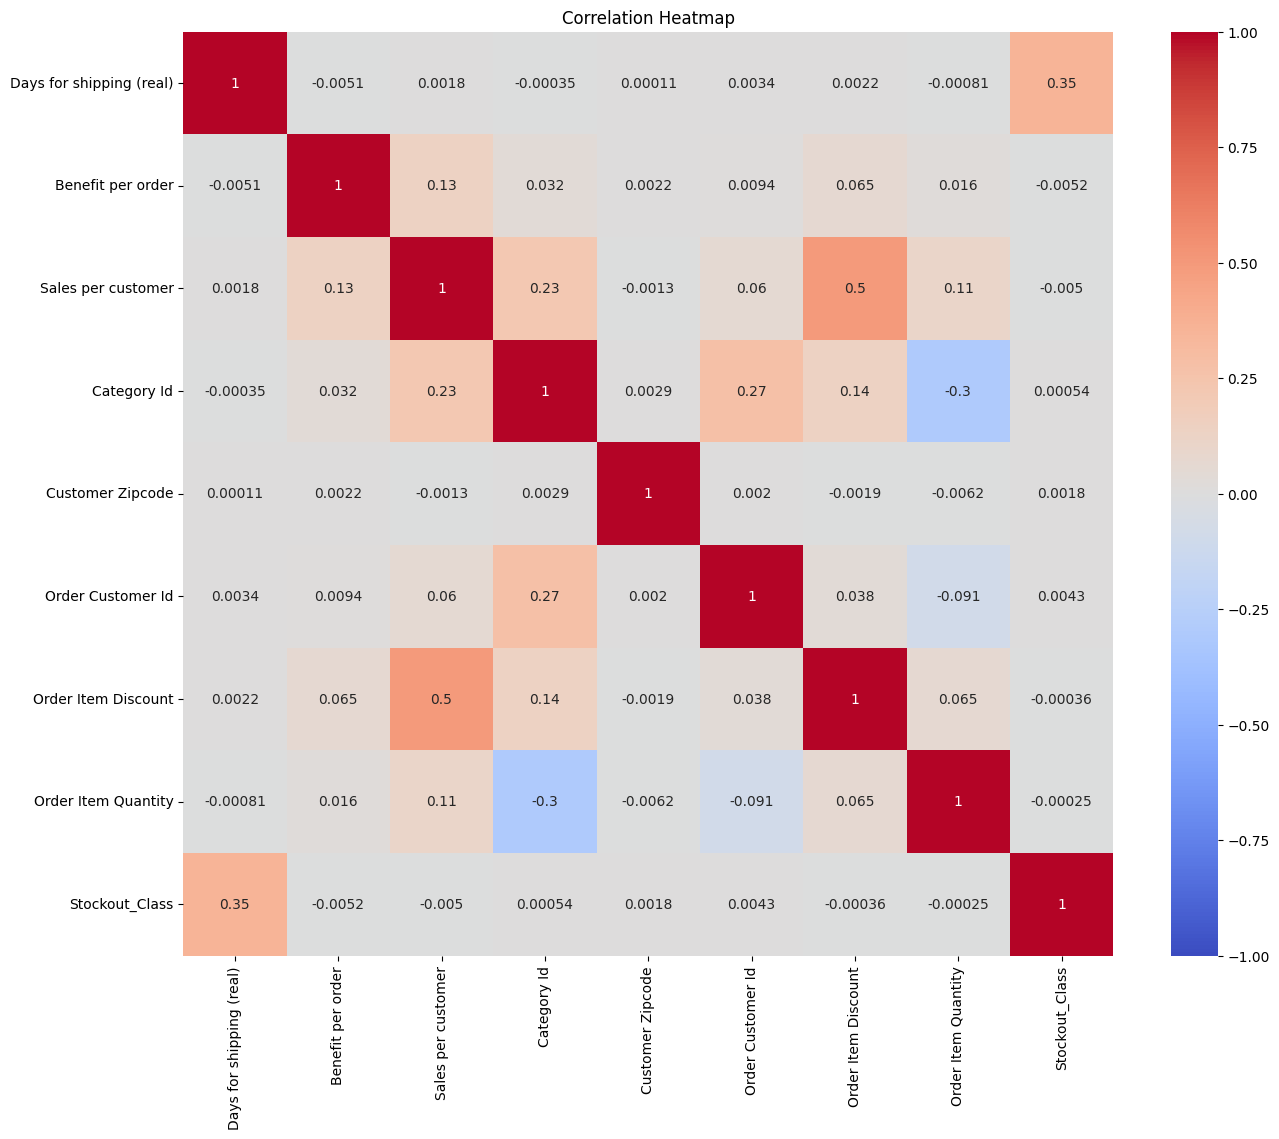

In [60]:
# Selecting numerical features only
df_numeric = data.select_dtypes(include=['float64', 'int64'])
numerical_cols = df_numeric.columns.tolist()

# Heatmap on numerical features
plt.figure(figsize=(15, 12))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

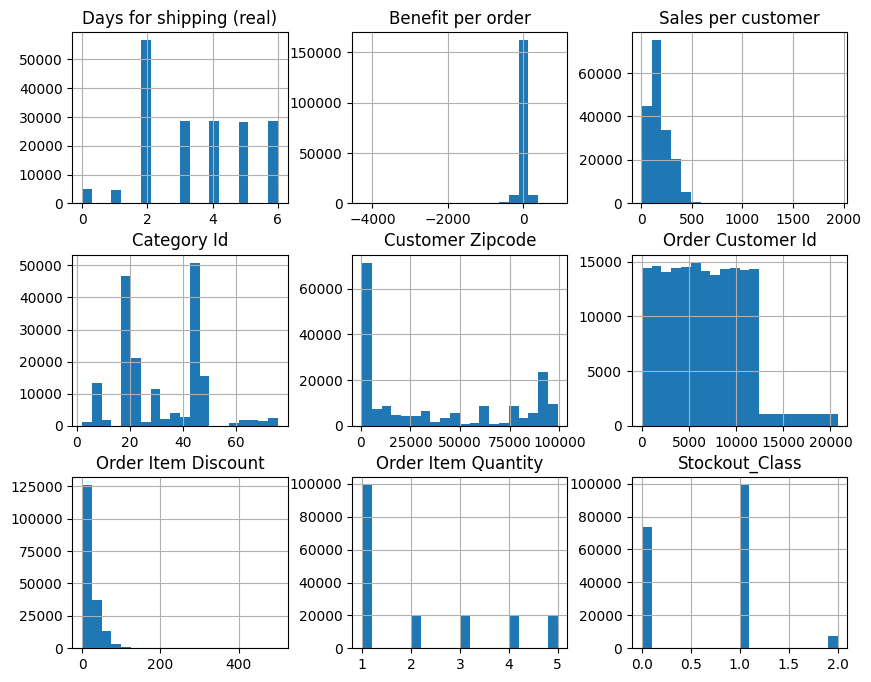

In [61]:
# Histogram for numerical variables
df_numeric.hist(bins=20, figsize=(10, 8))
plt.show()

## Datetime fields

Converting relevant date columns to datetime objects for easier manipulation and analysis.

In [62]:
# Convert date columns to datetime objects
data['order date (DateOrders)'] = pd.to_datetime(data['order date (DateOrders)'])
data['shipping date (DateOrders)'] = pd.to_datetime(data['shipping date (DateOrders)'])

## Type conversions

The zip code is often too granular. I am converting that to a string type so I can apply a target encoding in the next steps.

In [63]:
# Ensure Zipcode is a string
data['Customer Zipcode'] = data['Customer Zipcode'].astype(int).astype(str)

## Categorical Features

**Distinguishing between categorical features with low and high cardinality.**

To prepare non-numeric categorical features for machine learning models, I will apply one-hot encoding to the low cardinality categorical & object variables, converting them into a suitable numerical format.

Frequency Encoding is often a better choice for high-cardinality categorical features than one-hot encoding, which can lead to sparsity, overfitting, and high dimensionality. By replacing categories with their relative proportions or frequencies, this method maintains valuable information while keeping the feature count manageable.


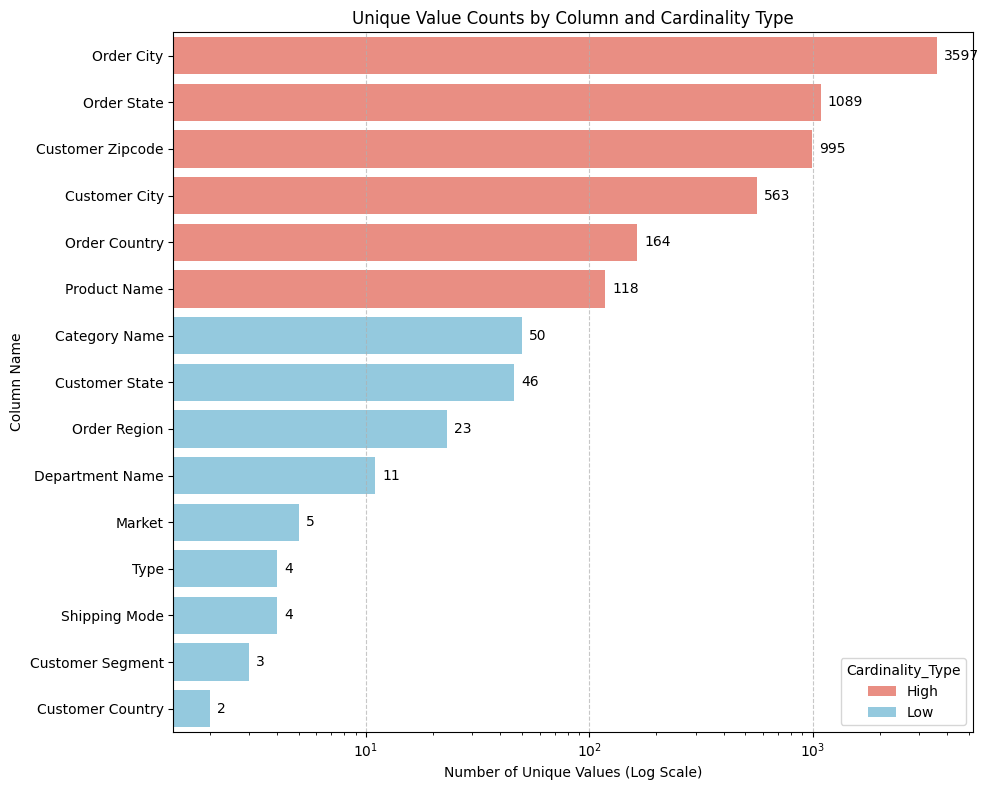

In [64]:
## Identify all object (categorical) columns
all_categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

max_distinct_values = 100
# Determine high and low cardinality columns based on a threshold (e.g., > max_distinct_values unique values)
high_cardinality_cols = []
low_cardinality_cols = []

for col in all_categorical_cols:
    if data[col].nunique() > max_distinct_values:
        high_cardinality_cols.append(col)
    else:
        low_cardinality_cols.append(col)

#print(f"Low cardinality columns for One-Hot Encoding: {low_cardinality_cols}")
#print(f"High cardinality columns for Frequency Encoding: {high_cardinality_cols}")

# Create a DataFrame for low cardinality columns
low_cardinality_counts = {col: data[col].nunique() for col in low_cardinality_cols}
df_low_card = pd.DataFrame(list(low_cardinality_counts.items()), columns=['Column', 'Unique Count'])

# Create a DataFrame for high cardinality columns
high_cardinality_counts = {col: data[col].nunique() for col in high_cardinality_cols}
df_high_card = pd.DataFrame(list(high_cardinality_counts.items()), columns=['Column', 'Unique Count'])

# Combine the two dataframes for a single plot
df_all_cardinality = pd.concat([
    df_low_card.assign(Cardinality_Type='Low'),
    df_high_card.assign(Cardinality_Type='High')
])

# Sort by Unique Count for better visualization
df_all_cardinality = df_all_cardinality.sort_values(by='Unique Count', ascending=False)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x='Unique Count', y='Column', hue='Cardinality_Type', data=df_all_cardinality, palette={'Low': 'skyblue', 'High': 'salmon'})
plt.title('Unique Value Counts by Column and Cardinality Type')
plt.xlabel('Number of Unique Values (Log Scale)')
plt.ylabel('Column Name')
plt.xscale('log') # Use a logarithmic scale for the x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add numbers on top of bars
for p in ax.patches:
    width = p.get_width()
    # Convert width to int for display, as log scale messes with precision
    ax.annotate(f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), # distance from bar
                textcoords='offset points')

plt.tight_layout()
plt.show()

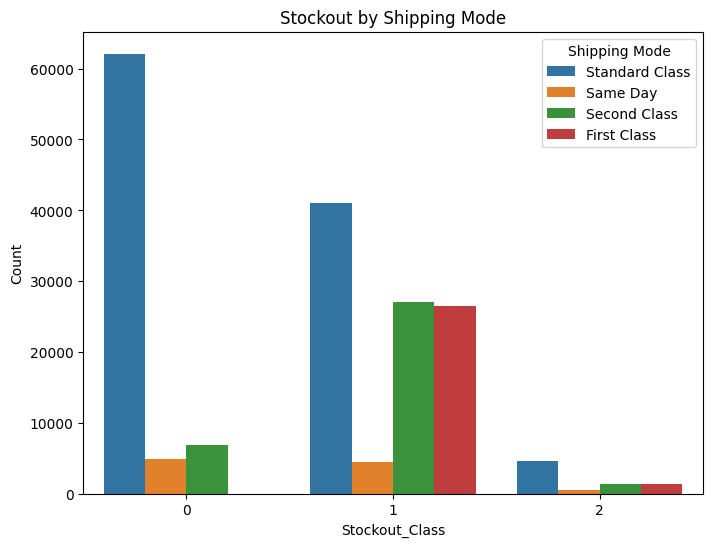

In [65]:
# Shipping Mode vs Stockout_Class
plt.figure(figsize=(8, 6))
sns.countplot(x='Stockout_Class', hue='Shipping Mode', data=data)
plt.title('Stockout by Shipping Mode')
plt.xlabel('Stockout_Class')
plt.ylabel('Count')
plt.show()

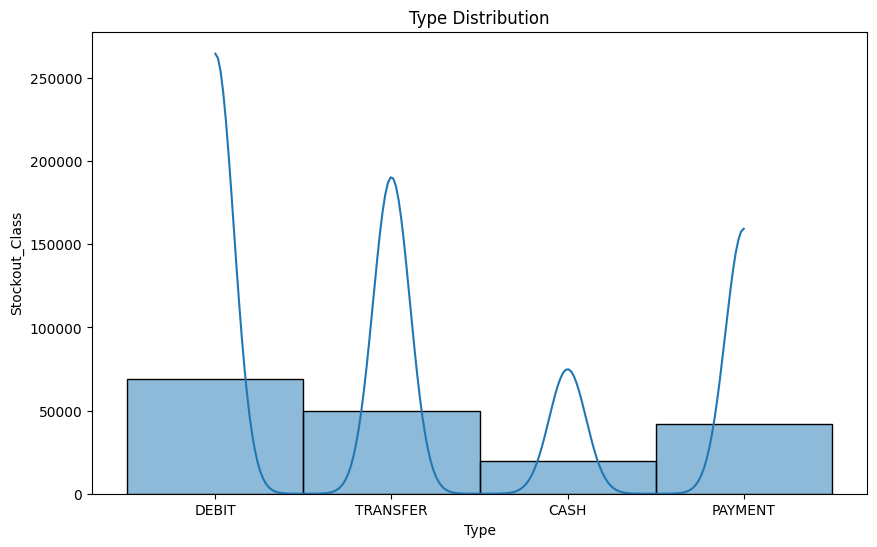

In [66]:
# Type distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Type'].dropna(), bins=80, kde=True)
plt.title('Type Distribution')
plt.xlabel('Type')
plt.ylabel('Stockout_Class')
plt.show()

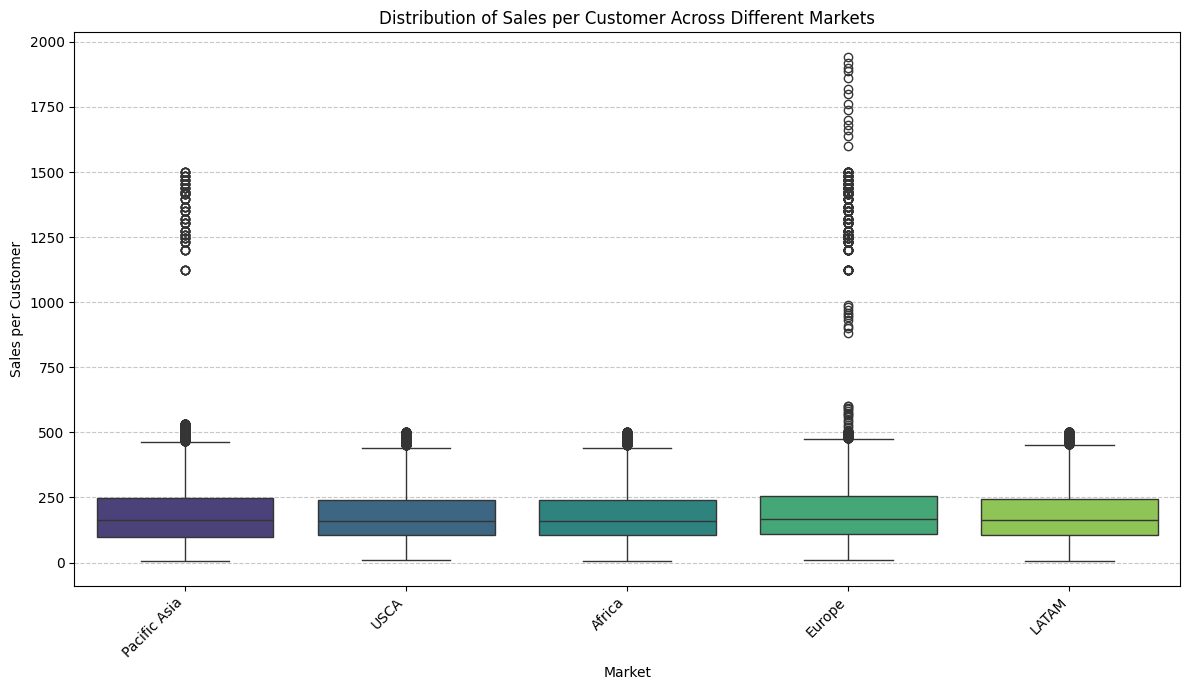

In [67]:
# Market Distribution
plt.figure(figsize=(12, 7))
sns.boxplot(x='Market', y='Sales per customer', data=data, palette='viridis')
plt.title('Distribution of Sales per Customer Across Different Markets')
plt.xlabel('Market')
plt.ylabel('Sales per Customer')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

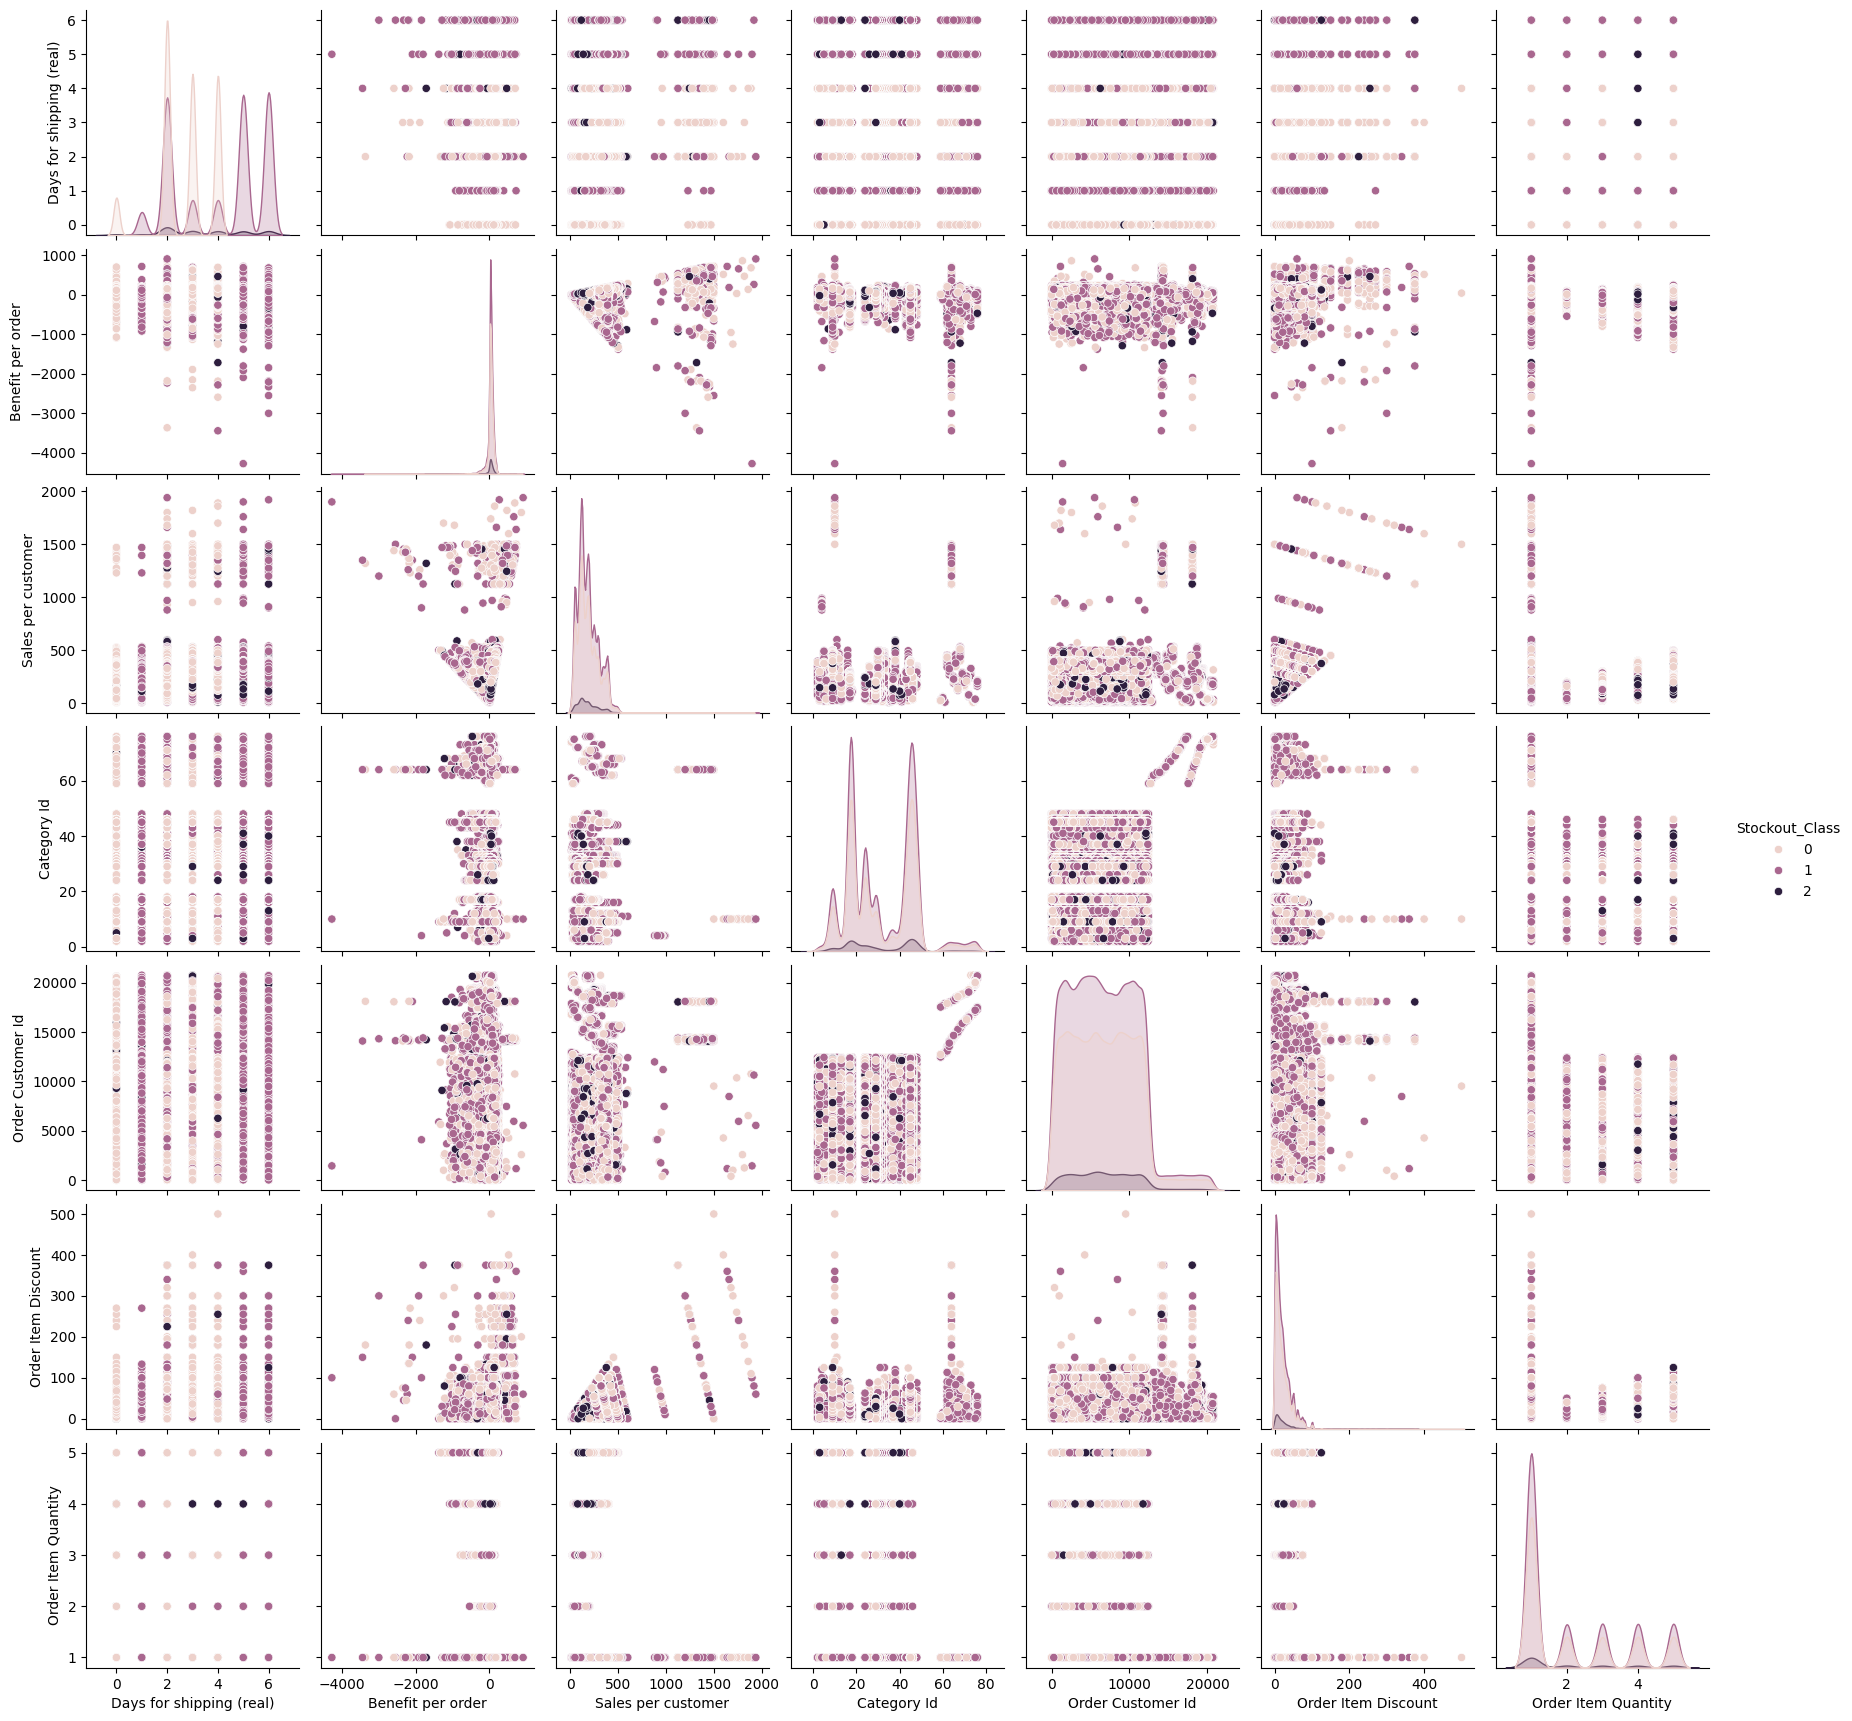

In [68]:
sns.pairplot(data, hue="Stockout_Class")
plt.show()

## Outliers

In [69]:
print('--- Outlier Detection using IQR Method ---')

outlier_counts = {}

# Select only numerical columns for outlier detection
for column in data.select_dtypes(include=['number']).columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    if not outliers.empty:
        outlier_counts[column] = len(outliers)

if outlier_counts:
    print("Number of outliers per numerical column (using IQR):")
    for col, count in outlier_counts.items():
        print(f"  {col}: {count} outliers")
else:
    print("No significant outliers found in numerical columns using the IQR method.")

--- Outlier Detection using IQR Method ---
Number of outliers per numerical column (using IQR):
  Benefit per order: 18942 outliers
  Sales per customer: 1943 outliers
  Order Customer Id: 1198 outliers
  Order Item Discount: 7537 outliers


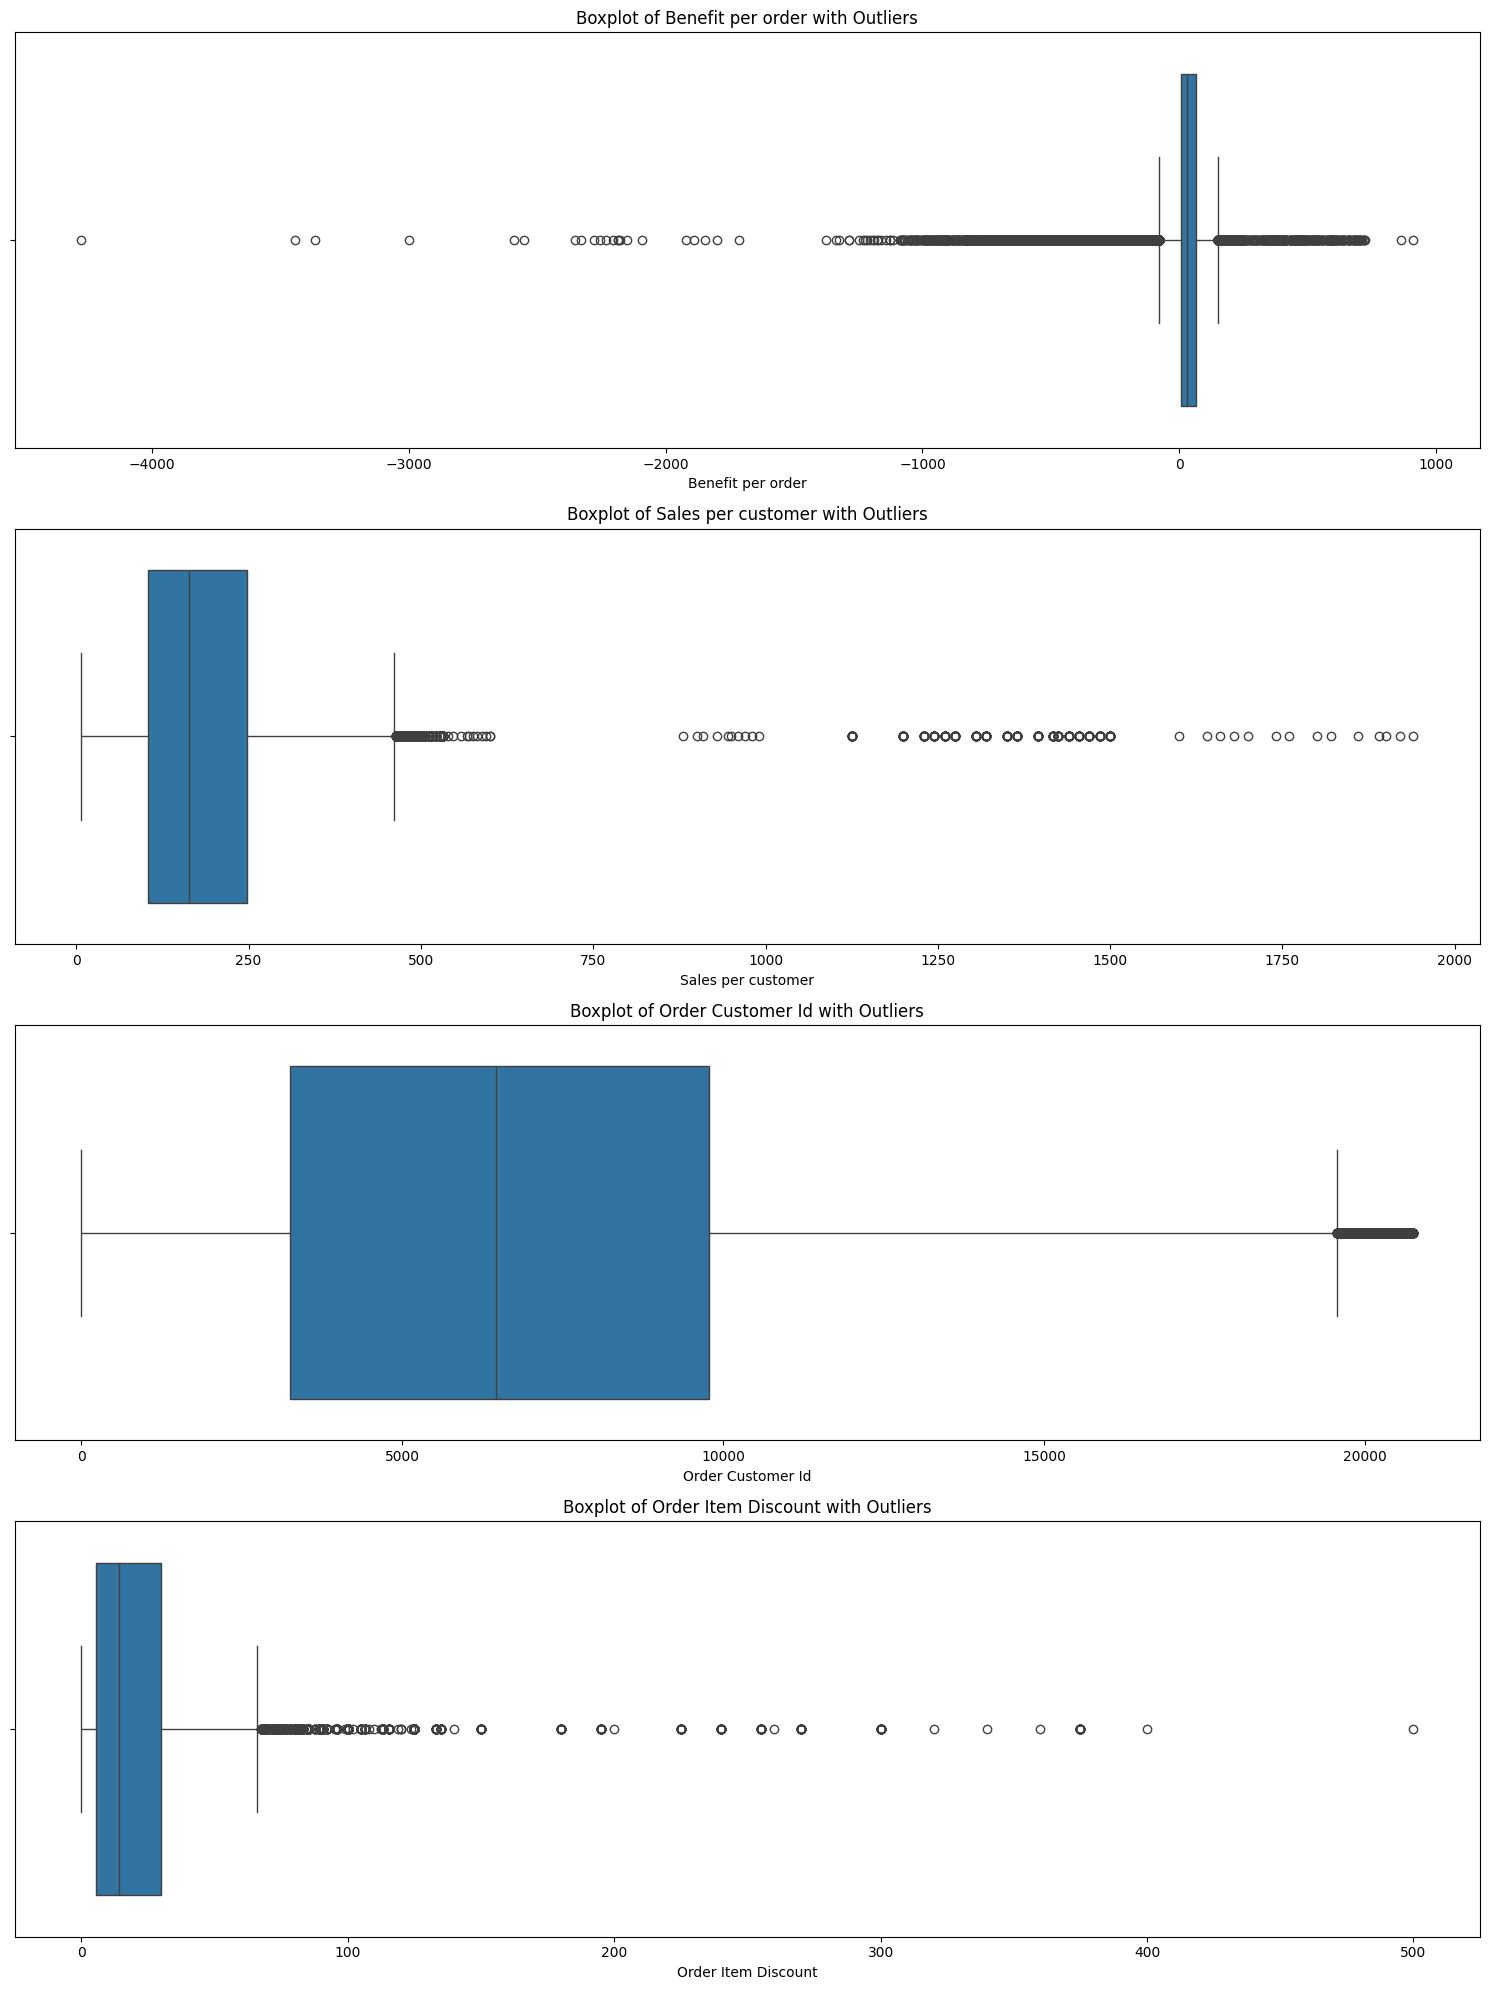

In [70]:
plt.figure(figsize=(15, 5 * len(outlier_counts)))
for i, col in enumerate(outlier_counts.keys()):
    plt.subplot(len(outlier_counts), 1, i + 1)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col} with Outliers')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

### Outlier Removal

Based on the IQR method, I will remove the identified outliers from the `data` DataFrame.

In [71]:
# Remove outliers for each identified column
initial_rows = data.shape[0]

for column in outlier_counts.keys():
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    print(f"Removed outliers for '{column}'. New shape: {data.shape}")

final_rows = data.shape[0]
rows_removed = initial_rows - final_rows
print(f"\nTotal rows removed: {rows_removed}")
print(f"New shape of data after outlier removal: {data.shape}")

Removed outliers for 'Benefit per order'. New shape: (161577, 25)
Removed outliers for 'Sales per customer'. New shape: (160370, 25)
Removed outliers for 'Order Customer Id'. New shape: (159111, 25)
Removed outliers for 'Order Item Discount'. New shape: (152073, 25)

Total rows removed: 28446
New shape of data after outlier removal: (152073, 25)


**Descriptive Statistics of Numerical Variables (After Cleaning and Outlier Removal**

In [72]:
display(data.describe())

,Days for shipping (real),Benefit per order,Sales per customer,Category Id,Order Customer Id,order date (DateOrders),Order Item Discount,Order Item Quantity,shipping date (DateOrders),Stockout_Class
count,152073.000000,152073.000000,152073.000000,152073.000000,152073.000000,152073,152073.000000,152073.000000,152073,152073.000000
mean,3.495190,37.058225,162.454201,30.890724,6518.093922,2016-06-02 17:21:17.733325568,16.861694,2.124723,2016-06-06 05:15:58.149967616,0.633893
min,0.000000,-79.690002,7.490000,2.000000,2.000000,2015-01-01 00:00:00,0.000000,1.000000,2015-01-03 00:00:00,0.000000
25%,2.000000,11.340000,97.489998,18.000000,3206.000000,2015-09-16 11:33:00,5.000000,1.000000,2015-09-19 19:36:00,0.000000
50%,3.000000,33.110001,146.940002,29.000000,6352.000000,2016-06-01 17:40:00,12.500000,1.000000,2016-06-05 00:09:00,1.000000
75%,5.000000,61.650002,213.729996,45.000000,9633.000000,2017-02-15 13:58:00,25.490000,3.000000,2017-02-18 23:15:00,1.000000
max,6.000000,151.350006,436.100006,76.000000,19457.000000,2018-01-13 00:12:00,61.740002,5.000000,2018-01-18 21:02:00,2.000000
std,1.625129,41.667179,91.067451,14.760201,3950.988101,NaN,14.806709,1.419651,NaN,0.563956


# Preparations

### Developing a custom function for subsequent integration into a pipeline via a **FunctionTransformer** step.

In [73]:
datetime_cols = data.select_dtypes(include=['datetime']).columns.tolist()
# Define a function to extract datetime features
def extract_datetime_features(X_original):
    X = X_original.copy() # Avoid modifying the original DataFrame
    df_datetimes = X.select_dtypes(include=['datetime'])
    for col in df_datetimes.columns:
        prefix = col.split(' ')[0].lower()
        X[f'{prefix}_year'] = X[col].dt.year
        X[f'{prefix}_month'] = X[col].dt.month
        X[f'{prefix}_day'] = X[col].dt.day
        X[f'{prefix}_dayofweek'] = X[col].dt.dayofweek
        X[f'{prefix}_hour'] = X[col].dt.hour
        #drop the original datetime column within the transformer
        X = X.drop(columns=[col])
    return X

### Defining a **FrequencyEncoder** custom class to use for the categorical features with high cardinality

In [74]:
from sklearn.base import BaseEstimator, TransformerMixin

In [75]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.frequency_maps = {}
        self.columns_ = None # To store columns learned during fit

    def fit(self, X, y=None):
        # X is expected to be a DataFrame or 2D array, we iterate through its columns
        self.columns_ = X.columns # Store the column names
        for col in X.columns:
            self.frequency_maps[col] = X[col].value_counts(normalize=True).to_dict()
        return self

    def transform(self, X):
        X_encoded = X.copy()
        for col in X.columns:
            if col in self.frequency_maps:
                X_encoded[col] = X_encoded[col].map(self.frequency_maps[col]).fillna(0) # Handle unseen categories
            else:
                # If a column was not in fit, maybe it's numerical or should be passed through
                pass # Or raise an error, depending on desired behavior
        return X_encoded

    def get_feature_names_out(self, input_features=None):
        # For frequency encoding, the feature names remain the same as the input features
        # We can use the columns learned during fit or the input_features if provided
        if input_features is not None:
            return input_features
        elif self.columns_ is not None:
            return self.columns_
        else:
            raise RuntimeError("FrequencyEncoder has not been fitted or input_features not provided.")

print("FrequencyEncoder class defined.")

FrequencyEncoder class defined.


### Defining a **ColumnTransformer**

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

Now, we define the `ColumnTransformer`. It will handle:

*   **Numerical Features:** Imputation with the mean and `StandardScaler`.
*   **Low-Cardinality Categorical Features:** `OneHotEncoder`.
*   **High-Cardinality Categorical Features:** Our custom `FrequencyEncoder`.
*   **Datetime Features:** Our `extract_datetime_features` function using `FunctionTransformer`.

I'll use `remainder='passthrough'` to ensure any columns not explicitly mentioned in a transformer (like `Stockout_Class` if it were still in `X`) are kept, though in our `X_train` and `X_test` splits, the target is already separated.

In [77]:
# numerical_cols, low_cardinality_cols, high_cardinality_cols, and datetime_cols should be defined from X_train
# For simplicity, I am reusing the previously identified lists assuming they accurately reflect the feature columns in X_train

# Create a new list for numerical features to exclude 'Stockout_Class' (the target variable)
features_numerical_cols = [col for col in numerical_cols if col != 'Stockout_Class']

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), features_numerical_cols), # Applying to numerical columns, excluding the target
        ('low_cat', OneHotEncoder(handle_unknown='ignore', drop='first'), low_cardinality_cols), # Applying to low-cardinality categorical columns
        ('high_cat', FrequencyEncoder(), high_cardinality_cols), # Applying to high-cardinality categorical columns with custom encoder
        ('datetime_process', FunctionTransformer(extract_datetime_features, validate=False), datetime_cols) # Applying datetime feature extraction
    ],
    remainder='passthrough' # Keep other columns that are not transformed (e.g., if there are any original columns not in above lists)
)

# Split Data into Training (Train) and Testing (Test)

We are splitting our data into training and testing sets **before** we begin feature engineering or model training is **crucial**.

If we apply transformations prior to the split, we risk leaking information from the test set into the training phase. This results in overfitting, where the model's high performance metrics fail to accurately represent its ability to generalize to new, unseen data.


In [78]:
# Define a consistent random state for reproducibility
RANDOM_STATE = 42

In [79]:
from sklearn.model_selection import train_test_split

In [82]:
import warnings
warnings.filterwarnings("ignore")

# Separate features (X) and target (y)
X = data.drop(['Stockout_Class'], axis=1)
y = data['Stockout_Class']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (152073, 24)
Shape of target (y): (152073,)


In [83]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

### Distribution of Stockout Classes in Training and Test Sets

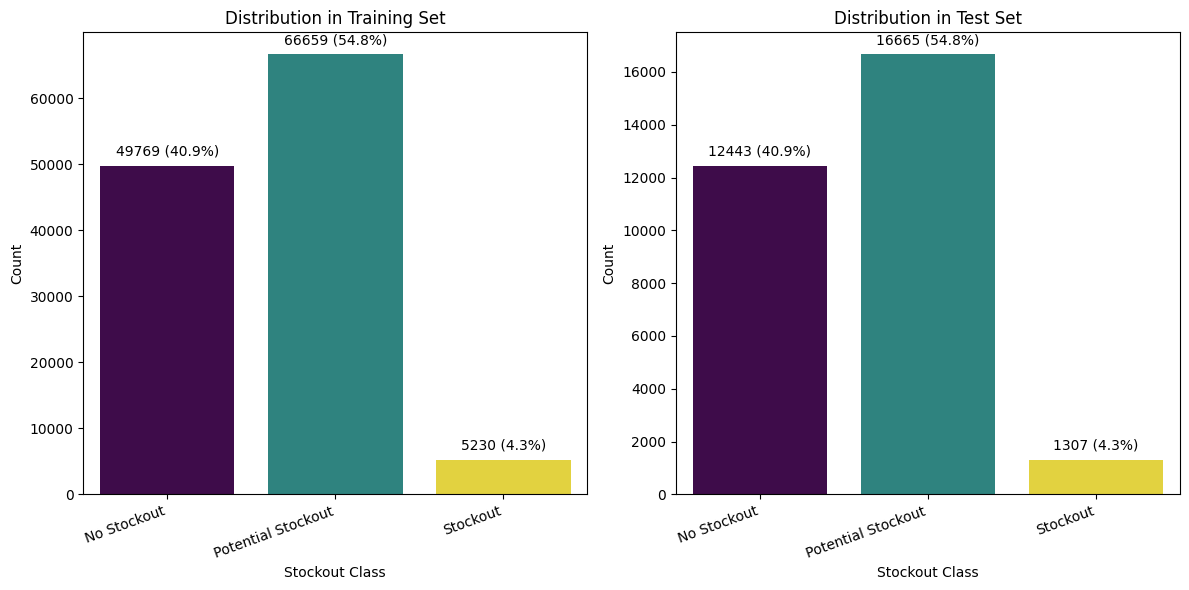

In [84]:
# Plot the distribution of the target variable in the training set
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
ax_train = sns.countplot(x=y_train, hue=y_train, palette='viridis', legend=False)
plt.title('Distribution in Training Set')
plt.xlabel('Stockout Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['No Stockout', 'Potential Stockout', 'Stockout'], rotation=20, ha='right')
total_train = len(y_train)
for p in ax_train.patches:
    height = p.get_height()
    ax_train.annotate(f'{int(height)} ({height/total_train:.1%})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Plot the distribution of the target variable in the testing set
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
ax_test = sns.countplot(x=y_test, hue=y_test, palette='viridis', legend=False)
plt.title('Distribution in Test Set')
plt.xlabel('Stockout Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['No Stockout', 'Potential Stockout', 'Stockout'], rotation=20, ha='right')
total_test = len(y_test)
for p in ax_test.patches:
    height = p.get_height()
    ax_test.annotate(f'{int(height)} ({height/total_test:.1%})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

- We use `fit_transform` ONLY on `X_train` to **learn** the parameters of the transformation.

- We use **only** `transform` on `X_test` to **apply** those same transformations, without recalculating the parameters. This ensures no data leakage and allows the model to **generalize** correctly.

In [85]:
X_train_processed = preprocessor.fit_transform(X_train).toarray()
X_test_processed = preprocessor.transform(X_test).toarray()

In [86]:
# The names of the numerical columns remain unchanged after the transformation
numerical_column_names = features_numerical_cols

# The method get_feature_names_out generates the names of the new columns created by OneHotEncoder for the categorical columns
low_categorical_column_names = preprocessor.named_transformers_['low_cat'].get_feature_names_out()

# The FrequencyEncoder keeps the original column names (due to its get_feature_names_out implementation)
high_categorical_column_names = preprocessor.named_transformers_['high_cat'].get_feature_names_out()

# Manually generate datetime feature names as created by extract_datetime_features
datetime_feature_names = []
for col in datetime_cols:
    prefix = col.split(' ')[0].lower().replace('(', '').replace(')', '') # Clean up prefix from 'order date (DateOrders)'
    datetime_feature_names.extend([
        f'{prefix}_year', f'{prefix}_month', f'{prefix}_day',
        f'{prefix}_dayofweek', f'{prefix}_hour'
    ])

# Combine all column names into a single list
all_column_names = list(numerical_column_names) + \
                   list(low_categorical_column_names) + \
                   list(high_categorical_column_names) + \
                   list(datetime_feature_names)

# Convert the matrix into a DataFrame with the column names
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_column_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_column_names)

# A Baseline Model

Establishing a baseline is an essential first step before constructing any model. We must determine the minimum level of performance our classifier needs to exceed to be effective.

## The Role of Baseline Accuracy

In classification tasks, baseline accuracy serves as a critical benchmark. It is defined as the accuracy achieved by consistently predicting the most frequent class in a dataset.

This is particularly important for imbalanced data, where a model might show high accuracy simply by favoring the majority class without actually identifying underlying patterns.

Consequently, for any machine learning model to be valuable, its performance must surpass this baseline.


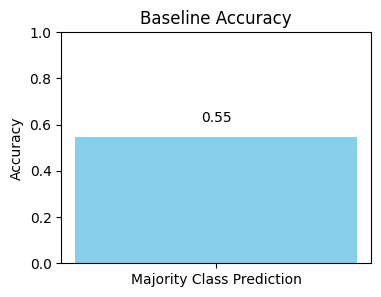

In [87]:
majority_class = y_train.value_counts().idxmax()
baseline_accuracy = (y_test == majority_class).mean()

#print(f"The calculated baseline accuracy is: {baseline_accuracy:.4f}")

# You can also visualize it if you want, for instance with a bar chart
plt.figure(figsize=(4, 3))
plt.bar(['Majority Class Prediction'], [baseline_accuracy], color='skyblue')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.title('Baseline Accuracy')
plt.ylabel('Accuracy')
plt.text(0, baseline_accuracy + 0.05, f'{baseline_accuracy:.2f}', ha='center', va='bottom') # Add text on top of the bar
plt.show()

# Balancing the dataset

## Distribution of Target


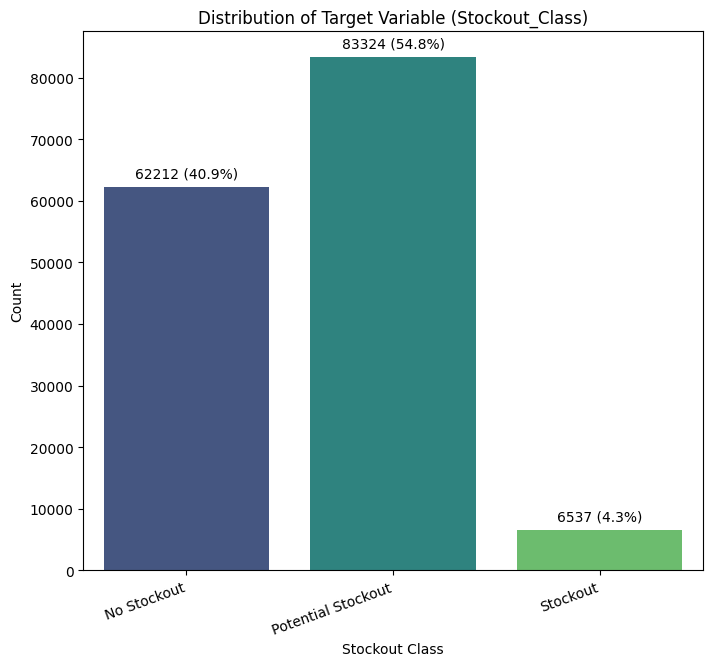

In [88]:
# Plot the distribution of the target variable
plt.figure(figsize=(8, 7))
ax = sns.countplot(x='Stockout_Class', data=data, palette='viridis')
plt.title('Distribution of Target Variable (Stockout_Class)')
plt.xlabel('Stockout Class')
plt.ylabel('Count')

# Set custom x-axis tick labels
plt.xticks(ticks=[0, 1, 2], labels=['No Stockout', 'Potential Stockout', 'Stockout'], rotation=20, ha='right')

total = len(data['Stockout_Class'])
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)} ({height/total:.1%})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

The dataset is clearly imbalanced. To address this, we will use SMOTE in the subsequent steps to expand the minority class by increasing its sample count.

## SMOTE

In classification tasks, verifying data balance is essential to prevent models from developing a bias toward the majority class, which can lead to poor performance on underrepresented data. Ensuring a balanced dataset allows the model to learn from all classes equally, enhancing its generalization and accuracy for critical applications like fraud detection and medical diagnoses.

### How to balance the data?
Mixing SMOTE (over-sampling) with Tomek Links (under-sampling) is widely considered one of the most sophisticated ways to handle imbalanced data. It is often referred to as SMOTETomek.

Here is why this "Hybrid" approach works so well for your stockout prediction:

### The Strategy: "Fill and Clean"
- **The SMOTE Part:** First, the algorithm creates synthetic "Yes" cases to give the minority class more presence. However, SMOTE is "blind"—it often creates these synthetic points right in the middle of the "No" class territory, creating a messy, overlapping border.

- **The Tomek Links Part:** Then, the algorithm identifies "Tomek Links" (pairs of points from different classes that are each other's nearest neighbors). It removes the majority class member of these pairs.

- **The Result:** You get a balanced dataset with a wide, clear "No-Man's Land" between your stockouts and your regular orders. This makes it much easier for models like SVC and Decision Trees to find a reliable decision boundary.

### Key considerations
- Always balance only the **training** set, not the test set.
- Compare model performance with and without balancing.
- Choose the balancing method carefully, as oversampling can lead to overfitting, and undersampling may lose important information.

In [89]:
from imblearn.over_sampling import SMOTE # pip install imbalanced-learn
from imblearn.combine import SMOTETomek
from collections import Counter

In [90]:
# Initialize SMOTE
smote = SMOTETomek(random_state=RANDOM_STATE)

# Apply SMOTE to balance the dataset
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed_df, y_train)

### Visualizing Class Distribution After SMOTETomek

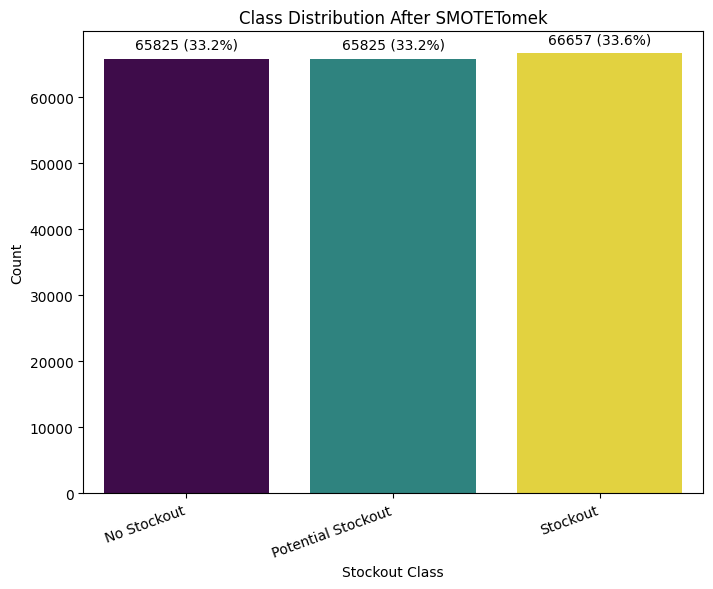

In [91]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x=y_train_balanced, hue=y_train_balanced, palette='viridis', legend=False)
plt.title('Class Distribution After SMOTETomek')
plt.xlabel('Stockout Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['No Stockout', 'Potential Stockout', 'Stockout'], rotation=20, ha='right')

total_balanced = len(y_train_balanced)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)} ({height/total_balanced:.1%})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

# A Simple Model
I will use **Logistic Regression** to build a basic model on the data.

A Helper method to evaluate the given method and return a dictionary with results

In [92]:
import time
from sklearn.metrics import classification_report

In [93]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
  model_name = model.__class__.__name__
  print(f"Evaluating {model_name}...")

  # Train the model and measure time
  start_time = time.time()
  model.fit(X_train, y_train)
  end_time = time.time()
  train_time = end_time - start_time

  # Training Accuracy
  train_accuracy = model.score(X_train, y_train)
  # Test Accuracy
  test_accuracy = model.score(X_test, y_test)

  # Predict
  y_pred = model.predict(X_test)

  # Generate classification report
  report = classification_report(y_test, y_pred, output_dict=True)

  # Return a dictionary with all metrics
  return {
      'Model': model_name,
      'Train Time': train_time,
      'Train Accuracy': train_accuracy,
      'Test Accuracy': test_accuracy,
      'Recall (Class 0)': report['0']['recall'],
      'Precision (Class 0)': report['0']['precision'],
      'F1-Score (Class 0)': report['0']['f1-score'],
      'Recall (Class 1)': report['1']['recall'],
      'Precision (Class 1)': report['1']['precision'],
      'F1-Score (Class 1)': report['1']['f1-score'],
      'Recall (Class 2)': report['2']['recall'],
      'Precision (Class 2)': report['2']['precision'],
      'F1-Score (Class 2)': report['2']['f1-score'],
      'Classification Report': report
  }

In [94]:
from sklearn.linear_model import LogisticRegression

In [95]:
# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear')

# Evaluate the model and store the result in a temporary variable
model_evaluation_result = evaluate_model(log_reg_model, X_train_balanced, y_train_balanced, X_test_processed_df, y_test)

Evaluating LogisticRegression...


### Accuracy

In [98]:
evals = pd.DataFrame.from_dict(model_evaluation_result, orient='index', columns=[''])
display(evals.drop(['Classification Report'], axis=0))

,
Model,LogisticRegression
Train Time,23.634014
Train Accuracy,0.83814
Test Accuracy,0.801447
Recall (Class 0),0.829462
Precision (Class 0),0.987372
F1-Score (Class 0),0.901555
Recall (Class 1),0.775878
Precision (Class 1),0.995994
F1-Score (Class 1),0.872264


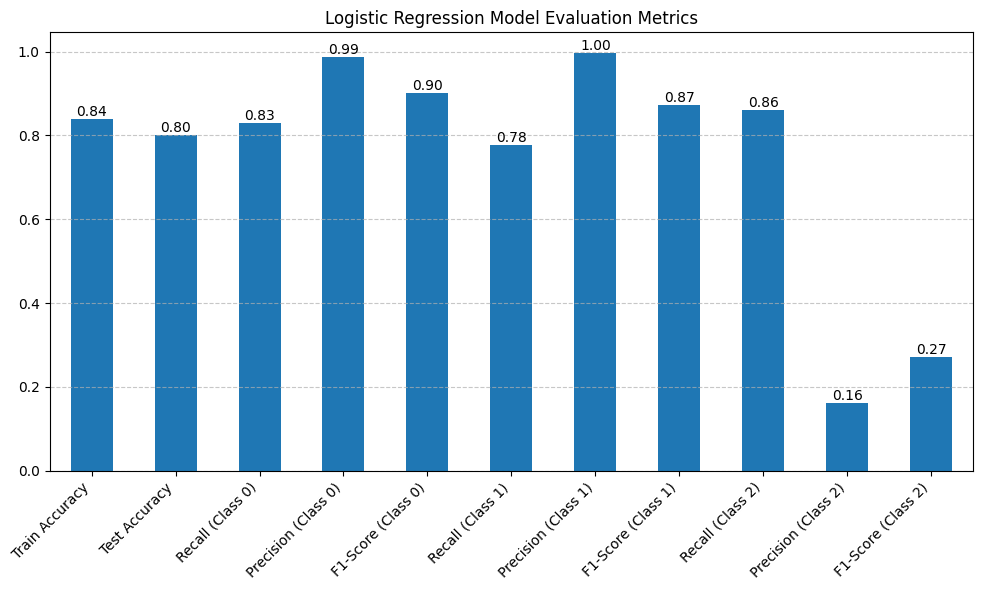

In [99]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = evals.drop(['Model','Classification Report', 'Train Time'])
metrics_to_plot.plot(kind='bar', ax=ax, legend=False)

# Put the values on top of the bar with two decimals
for i, value in enumerate(metrics_to_plot.values):
    ax.text(i, value[0], f'{value[0]:.2f}', ha='center', va='bottom')

ax.set_title('Logistic Regression Model Evaluation Metrics')
ax.set_xticks(range(len(metrics_to_plot.index)))
ax.set_xticklabels(metrics_to_plot.index, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Classification Report

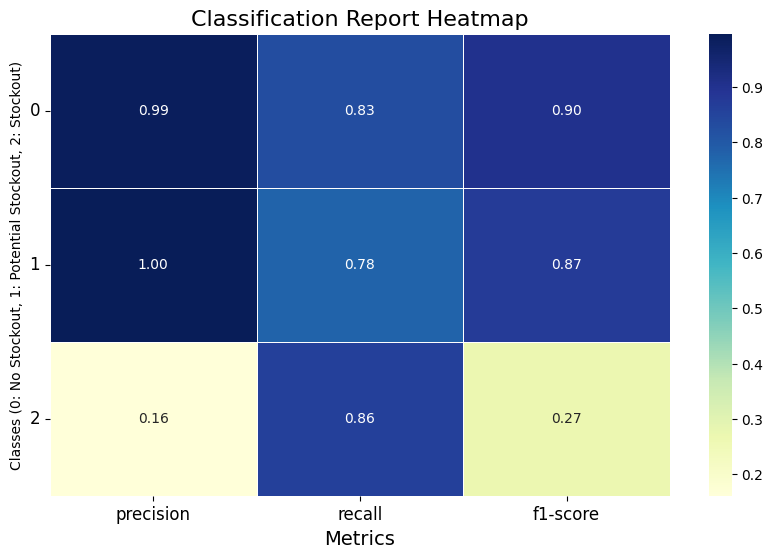

In [100]:
y_pred = log_reg_model.predict(X_test_processed_df)

classification_report = model_evaluation_result['Classification Report']
# Convert the dictionary to a DataFrame for easier visualization
df_report = pd.DataFrame(classification_report).transpose()

# Drop 'accuracy', 'macro avg', and 'weighted avg' rows for the heatmap as they are summary rows
df_report = df_report.drop(labels=['accuracy', 'macro avg', 'weighted avg'])

# Select the metrics to visualize (precision, recall, f1-score)
metrics_to_plot = df_report[['precision', 'recall', 'f1-score']]

# Create the heatmap for the classification report
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_to_plot, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5, annot_kws={'size': 10})
plt.title('Classification Report Heatmap', fontsize=16) # Increased title font size
plt.xlabel('Metrics', fontsize=14) # Increased x-label font size
plt.ylabel('Classes (0: No Stockout, 1: Potential Stockout, 2: Stockout)', fontsize=10)
plt.xticks(fontsize=12) # Increased x-tick font size
plt.yticks(fontsize=12, rotation=0) # Increased y-tick font size and set rotation to 0 for better readability
plt.show()

## Feature Importance

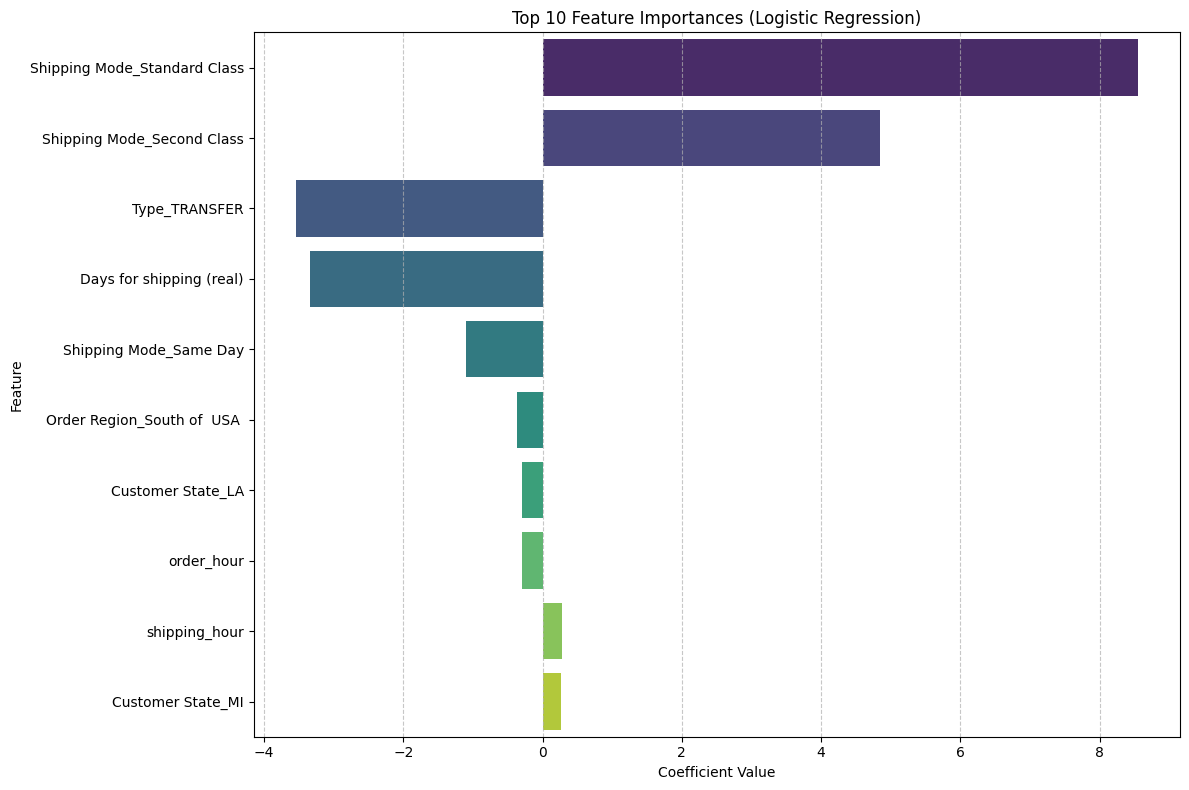

In [101]:
feature_importance = pd.DataFrame({
    'Feature': all_column_names,
    'Coefficient': log_reg_model.coef_[0]
})

feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The Logistic Regression model's feature importance highlights:

**Shipping Mode:** 'Standard Class' and 'Second Class' are strongly correlated with certain stockout classes.

**Order Type:** 'TRANSFER' orders are less associated with stockouts.

**Delivery Timelines:** The timing of orders and shipments (day/hour) influences stockout risk, with 'Days for shipping (real)' showing an inverse relationship.

**Geographical Factors:** Regional dynamics, such as 'Order Region_North America' and 'Order Region_Western Asia', also play a role.

## Key Observations

*   **Overall Accuracy:** The Logistic Regression model achieved an overall test accuracy of **80.32%**, which is a significant improvement over the baseline accuracy of 54.83%. This indicates the model is performing better than random chance.

*   **Strong Performance for Majority Classes (0 and 1):**
    *   For **Class 0 ('No Stockout')**, the model demonstrates very high precision (0.99) and recall (0.83). This means it is highly effective at correctly identifying orders with no stockout risk and rarely misclassifies them.
    *   For **Class 1 ('Potential Stockout')**, performance is also strong with high precision (1.00) and recall (0.78). This shows the model effectively identifies orders with a late delivery risk.

*   **Challenges with Minority Class (2 - 'Stockout'):**
    *   **High Recall (0.86) for Class 2:** The model is good at *identifying* actual 'Stockout' events. This is crucial for catching potential supply chain issues.
    *   **Very Low Precision (0.16) for Class 2:** This is the primary area of concern. While the model catches many stockouts, it also incorrectly flags a large number of non-stockout orders (from Class 0 and Class 1) as stockouts. This leads to a high number of false positives for the 'Stockout' category.

*   **Impact of SMOTETomek:** The use of SMOTETomek successfully balanced the training data, enabling the model to learn from the minority 'Stockout' class more effectively, as evidenced by the high recall for Class 2. However, it also appears to have made the model overly sensitive, leading to the low precision for Class 2.

In essence, the current model is highly effective at *detecting* stockouts (high recall) but tends to be overly cautious, leading to many false alarms (low precision). This trade-off needs to be carefully considered depending on the business impact of false positives versus false negatives in a real-world supply chain scenario.

# Classification Models

In machine learning, it is common to train several models that are appropriate for the task at hand (in this case, classification) and then choose the best model based on its performance.

This time, I will train:
- Logistic Regression
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Decision Trees
- Random Forest -- Ensemble model
- XGBoost -- Ensemble model

In [102]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [103]:
models = {
    'Logistic Regression': LogisticRegression(),
    'SVC': SVC(),
    'KNN': KNeighborsClassifier(),
    'DT': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Hyperparameter Tuning

### Applying Regularization via GridSearchCV

To address regularization:
- **L1 (Lasso):** Can zero out less important features.
- **L2 (Ridge):** Prevents coefficients from becoming too large.

Below is the corrected grid search that optimizes for the 'Confirmed Stockout' class while ensuring the data structures are aligned.

# Selecting Best Model

# Model interpretation

# Feature Importances

# Result

## Main takeaways

## Conclusions

## Future work